In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import sys
import pandas as pd

import cogwheel.cosmology
import cogwheel.data
import cogwheel.posterior
import cogwheel.sampling
import cogwheel.gw_plotting
import cogwheel.gw_utils

import gwosc
import gwpy.table
from pesummary.io import read

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
from parameter_estimation import load_posterior_samples, add_derived_quantities
from pe_injections import chirp_mass

In [17]:
# test out the auxiliary prior, get a sense of the standard params
aux_prior = cogwheel.gw_prior.LVCPrior(
    f_ref=100.0,
    mchirp_range=(10, 50),
    detector_pair='HL',
    tgps=0,
    ref_det_name='H',
    f_avg=100.0,
    d_hat_max=100.0,
    dt0=0.01,
)

# draws from the prior to get a sense of the possible values
# instantiate an empty dict
prior_draws = {}
# and make these empty lists
for key in aux_prior.standard_params:
    prior_draws[key] = []
prior_draws['chieff'] = []
# just use a bunch of seeds
ndraws = 2000
for seed in np.arange(ndraws):
    print(f"{(seed + 1) / ndraws * 100:.1f}%", end='\r')
    injection_dict = dict(aux_prior.generate_random_samples(1, seed=seed).loc[0, aux_prior.standard_params])
    # also add chieff
    injection_dict['chieff'] = cogwheel.gw_utils.chieff(injection_dict['m1'], injection_dict['m2'],
                                                            injection_dict['s1z'], injection_dict['s2z'])
    for key, value in injection_dict.items():
        prior_draws[key].append(value)

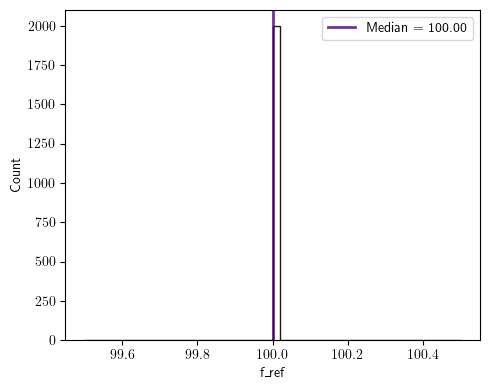

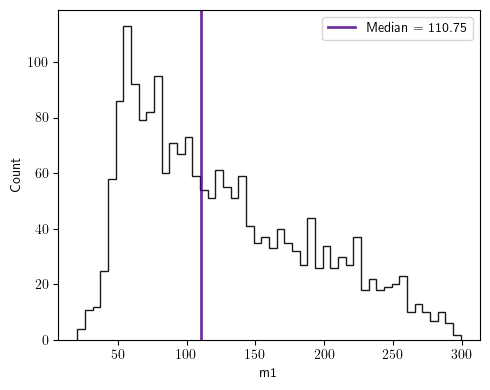

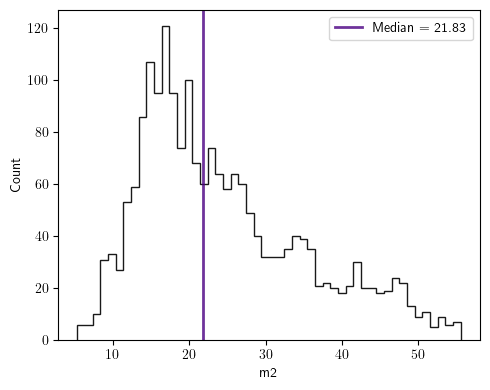

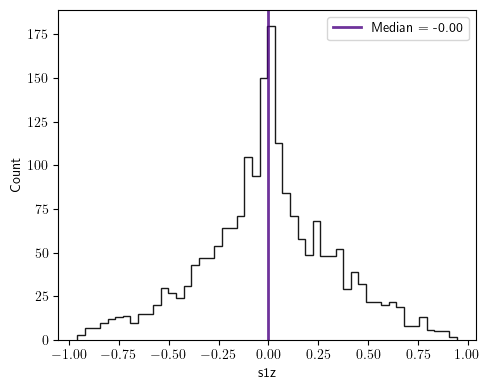

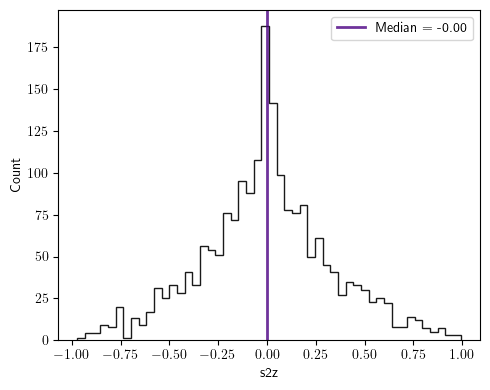

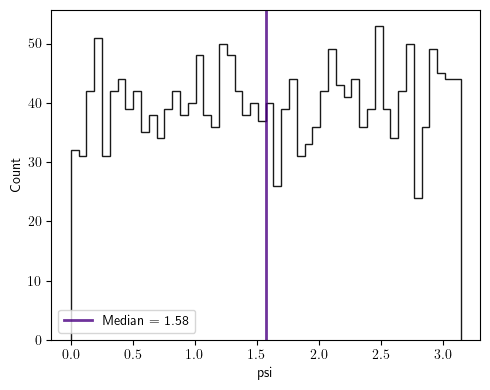

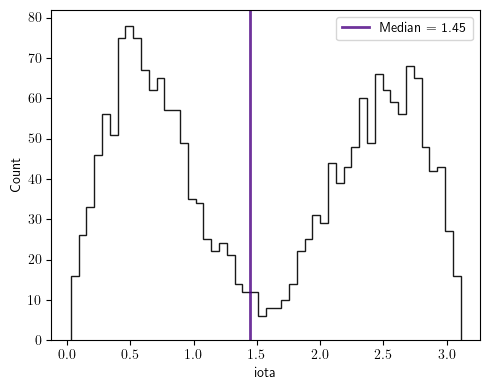

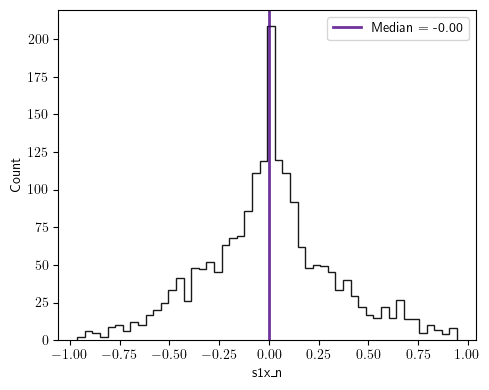

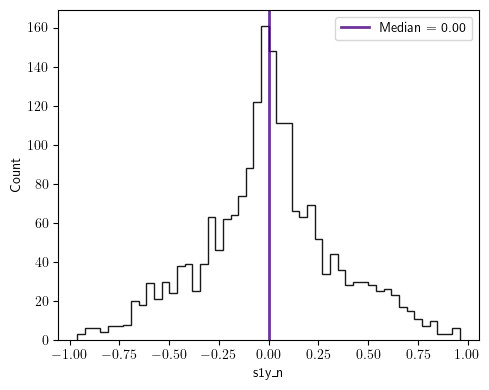

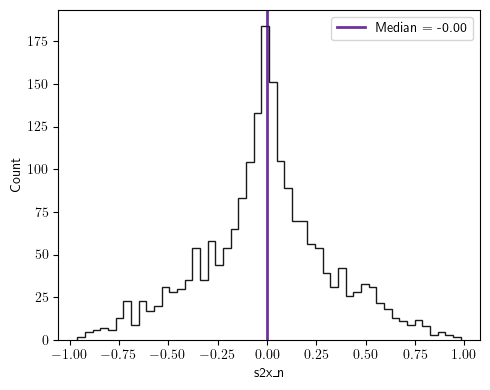

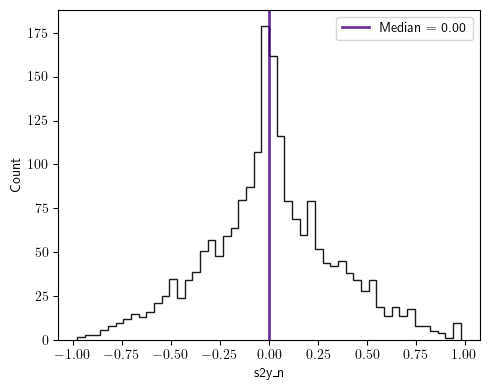

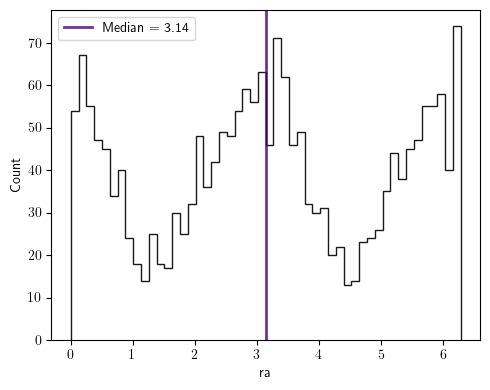

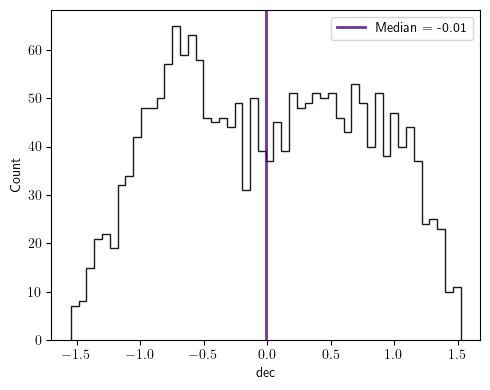

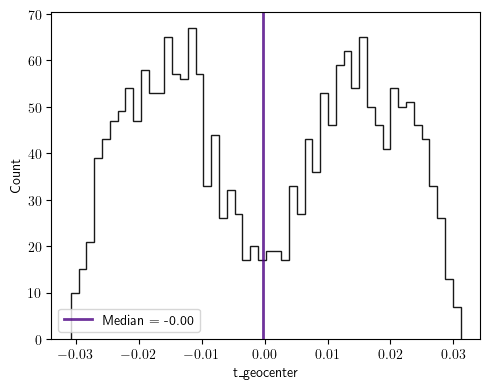

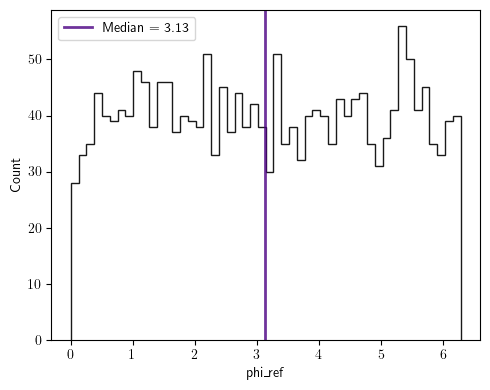

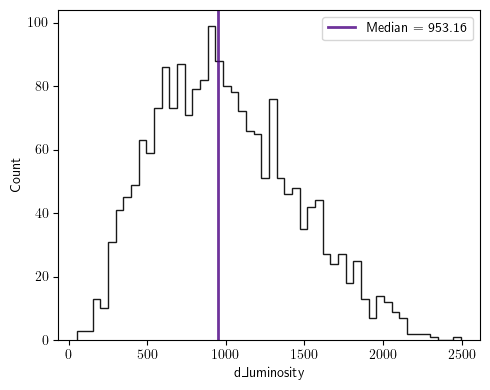

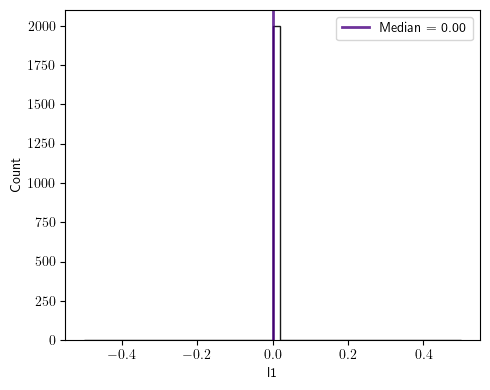

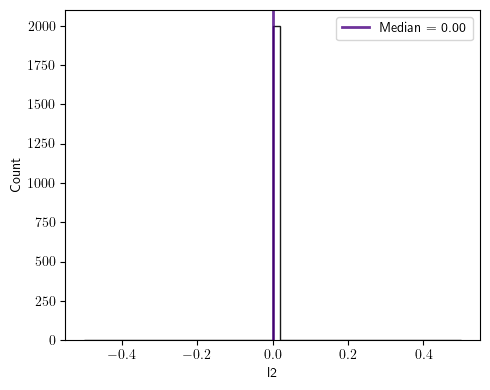

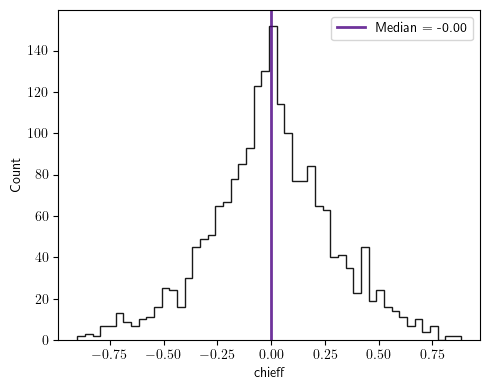

In [18]:
# histogram of each distribution
for key, values in prior_draws.items():
    fig, ax = plt.subplots(figsize=(5,4), tight_layout=True)
    _, _, _ = ax.hist(values, bins=50, color='k', histtype='step', alpha=0.9)
    median = np.median(values)
    ax.axvline(median, c='indigo', alpha=0.8, lw=2, label=f'Median = {median:.2f}')
    ax.set_xlabel(key)
    ax.set_ylabel('Count')
    ax.legend()

Text(0, 0.5, 'Dec (rad)')

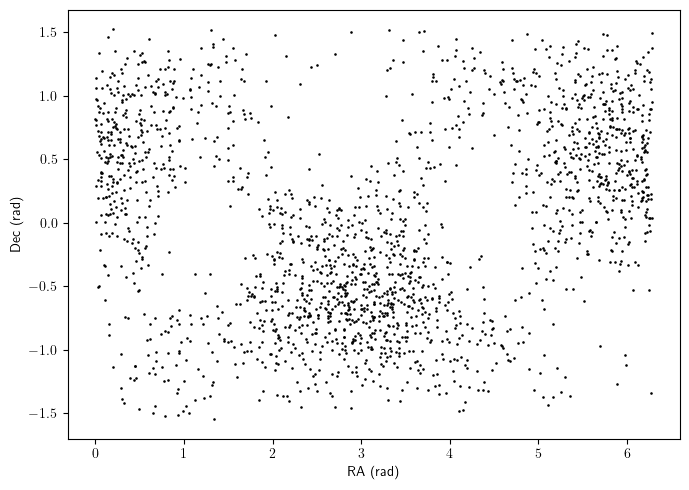

In [19]:
# (RA, Dec) pairs: where are the detector blind spots?
fig, ax = plt.subplots(figsize=(7,5), tight_layout=True)
ax.scatter(prior_draws['ra'], prior_draws['dec'], color='k', marker='.', s=3)
ax.set_xlabel('RA (rad)')
ax.set_ylabel('Dec (rad)')